In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
# OBTER DADOS
try:
    dados = pd.read_csv(
        '03.BaseDPEvolucaoMensalCisp.csv',
        sep=';', encoding='iso-8859-1')
    dp = pd.read_csv('08.DP.csv', sep=',', 
                     encoding='utf-8')
    # juntar com codDP
    df_comDP = dados.merge(dp, left_on='cisp',
                           right_on='codDP', how='left')
    
    # df_comDP.info()
    df_roubos = df_comDP[['cisp', 'nome', 'roubo_celular', 
                             'roubo_transeunte', 'ano', 'regiao', 'mes']]
    df_roubos.fillna('Delegacia não informada', inplace=True)
    df_roubos.info()
except Exception as e:
    print(f'Erro ao obter dados: {e}')
    

<class 'pandas.DataFrame'>
RangeIndex: 34848 entries, 0 to 34847
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   cisp              34848 non-null  int64
 1   nome              34848 non-null  str  
 2   roubo_celular     34848 non-null  int64
 3   roubo_transeunte  34848 non-null  int64
 4   ano               34848 non-null  int64
 5   regiao            34848 non-null  str  
 6   mes               34848 non-null  int64
dtypes: int64(5), str(2)
memory usage: 1.9 MB


In [3]:
roubo_celular_array = np.array(df_roubos['roubo_celular'])
roubo_transeunte_array = np.array(df_roubos['roubo_transeunte'])

# medidas de tendências centrais
roubo_celular_media = np.mean(roubo_celular_array)
roubo_celular_mediana = np.median(roubo_celular_array)
roubo_celular_delta_media_mediana = roubo_celular_media - roubo_celular_mediana
roubo_celular_proporcao_media_mediana = roubo_celular_media/roubo_celular_mediana

# transeunte
roubo_transeunte_media = np.mean(roubo_transeunte_array)
roubo_transeunte_mediana = np.median(roubo_transeunte_array)
roubo_transeunte_delta_media_mediana = roubo_transeunte_media - roubo_transeunte_mediana
roubo_transeunte_proporcao_media_mediana = roubo_transeunte_media/roubo_transeunte_mediana

# medidas de dispersão
roubo_celular_desvio_padrao = np.std(roubo_celular_array)
roubo_celular_variancia = np.var(roubo_celular_array)
roubo_celular_cv = roubo_celular_desvio_padrao/roubo_celular_media

# transeunte
roubo_transeunte_desvio_padrao = np.std(roubo_transeunte_array)
roubo_transeunte_variancia = np.var(roubo_transeunte_array)
roubo_transeunte_cv = roubo_transeunte_desvio_padrao/roubo_transeunte_media

# medidas de posição
roubo_celular_q1 = np.percentile(roubo_celular_array, 25)
roubo_celular_q3 = np.percentile(roubo_celular_array, 75)
roubo_celular_iqr = roubo_celular_q3 -  roubo_celular_q1
roubo_celular_max = np.max(roubo_celular_array)
roubo_celular_min = np.min(roubo_celular_array)
roubo_celular_amplitude = roubo_celular_max - roubo_celular_min
roubo_celular_limite_inferior = roubo_celular_q1 - 1.5*roubo_celular_iqr
roubo_celular_limite_superior = roubo_celular_q3 + 1.5*roubo_celular_iqr


# transeunte
roubo_transeunte_q1 = np.percentile(roubo_transeunte_array, 25)
roubo_transeunte_q3 = np.percentile(roubo_transeunte_array, 75)
roubo_transeunte_iqr = roubo_transeunte_q3 -  roubo_transeunte_q1
roubo_transeunte_max = np.max(roubo_transeunte_array)
roubo_transeunte_min = np.min(roubo_transeunte_array)
roubo_transeunte_amplitude = roubo_transeunte_max - roubo_transeunte_min
roubo_transeunte_limite_inferior = roubo_transeunte_q1 - 1.5*roubo_transeunte_iqr
roubo_transeunte_limite_superior = roubo_transeunte_q3 + 1.5*roubo_transeunte_iqr

# medidas de forma
roubo_celular_skewness = pd.Series(roubo_celular_array).skew()
roubo_celular_kurtosis = pd.Series(roubo_celular_array).kurtosis()

# transeunte
roubo_transeunte_skewness = pd.Series(roubo_transeunte_array).skew()
roubo_transeunte_kurtosis = pd.Series(roubo_transeunte_array).kurtosis()


In [4]:
print(f'Média de roubos de celular: {roubo_celular_delta_media_mediana}')
print(f'Assimetria de roubos de celular: {roubo_celular_skewness}')
print(f'Média de roubos a transeunte: {roubo_transeunte_delta_media_mediana}')
print(f'Assimetria de roubos a transeunte: {roubo_transeunte_skewness}')

Média de roubos de celular: 5.967487373737374
Assimetria de roubos de celular: 3.3718925483694226
Média de roubos a transeunte: 23.938475665748392
Assimetria de roubos a transeunte: 2.369312135564573


In [ ]:
# limites superiores e inferiores
df_roubos_celular_sup_superiores = df_roubos[df_roubos['roubo_celular'] > roubo_celular_limite_superior]
df_roubos_celular_lim_inferiores = df_roubos[df_roubos['roubo_celular'] < roubo_celular_limite_inferior]

# transeunte
df_roubos_transeunte_sup_superiores = df_roubos[df_roubos['roubo_transeunte'] > roubo_transeunte_limite_superior]
df_roubos_transeunte_lim_inferiores = df_roubos[df_roubos['roubo_transeunte'] < roubo_transeunte_limite_inferior]

# df_roubos_celular_sup_superiores

In [6]:
# delegacia com mais meses absolutos como outlier superior
delegacia_mais_outliers_superiores_celular = df_roubos_celular_sup_superiores['nome'].value_counts()
delegacia_mais_outliers_superiores_celular
# delegacia_mais_outliers_superiores = df_roubos_celular_sup_superiores.groupby('mes')['roubo_celular'].sum().reset_index().sort_values(by='roubo_celular', ascending=False)



nome
059ª DP - Duque de Caxias             174
034ª DP - Bangu                       119
029ª DP - Madureira                   113
023ª DP - Méier                       109
027ª DP - Vicente de Carvalho         104
064ª DP - São João de Meriti          103
033ª DP - Realengo                     98
052ª DP - Nova Iguaçu                  95
035ª DP - Campo Grande                 90
021ª DP - Bonsucesso                   83
054ª DP - Belford Roxo                 83
039ª DP - Pavuna                       81
058ª DP - Posse                        81
005ª DP - Mem de Sá                    76
018ª DP - Praça da Bandeira            75
032ª DP - Taquara                      74
056ª DP - Comendador Soares            73
057ª DP - Nilópolis                    61
038ª DP - Brás de Pina                 55
074ª DP - Alcântara                    54
031ª DP - Ricardo de Albuquerque       52
009ª DP - Catete                       49
016ª DP - Barra da Tijuca              48
072ª DP - São Gonçalo        

In [7]:
delegacia_mais_outliers_superiores_transeunte = df_roubos_transeunte_sup_superiores['nome'].value_counts()
delegacia_mais_outliers_superiores_transeunte

nome
059ª DP - Duque de Caxias           212
034ª DP - Bangu                     159
064ª DP - São João de Meriti        158
074ª DP - Alcântara                 138
027ª DP - Vicente de Carvalho        93
029ª DP - Madureira                  92
052ª DP - Nova Iguaçu                90
005ª DP - Mem de Sá                  84
035ª DP - Campo Grande               77
072ª DP - São Gonçalo                67
054ª DP - Belford Roxo               65
021ª DP - Bonsucesso                 61
073ª DP - Neves                      60
058ª DP - Posse                      57
039ª DP - Pavuna                     44
033ª DP - Realengo                   38
031ª DP - Ricardo de Albuquerque     37
057ª DP - Nilópolis                  34
040ª DP - Honório Gurgel             34
056ª DP - Comendador Soares          34
022ª DP - Penha                      29
023ª DP - Méier                      25
060ª DP - Campos Elíseos             21
075ª DP - Rio do Ouro                20
028ª DP - Praça Seca               

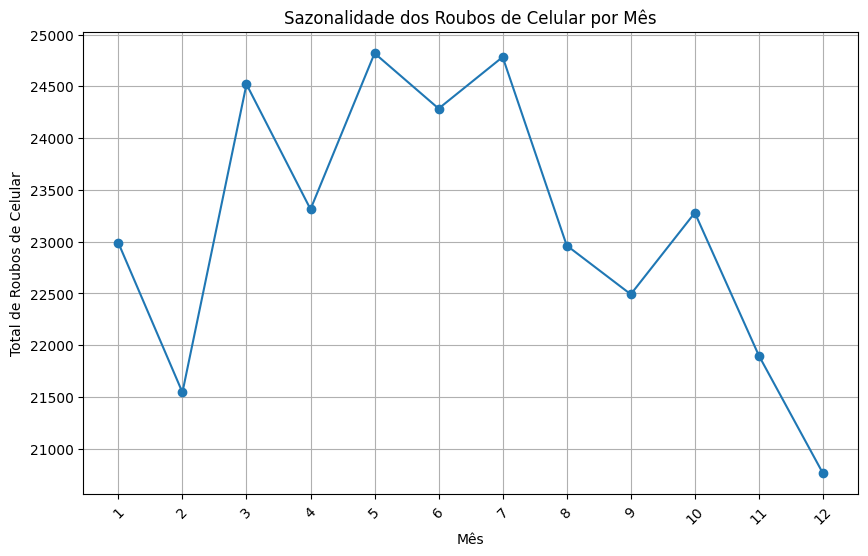

In [38]:
sazonalidade = df_roubos.groupby('mes')['roubo_celular'].sum().reset_index()
plt.figure(figsize=(10, 6))
plt.plot(sazonalidade['mes'].astype(str), sazonalidade['roubo_celular'], marker='o')
plt.title('Sazonalidade dos Roubos de Celular por Mês')
plt.xlabel('Mês')
plt.ylabel('Total de Roubos de Celular')
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [8]:
# Outliers por delegacia

def detectar_outliers(array):
    q1 = array.quantile(0.25)
    q3 = array.quantile(0.75)
    iqr = q3 - q1
    limite_sup = q3 + 1.5 * iqr
    # retorna todos os elementos do array com valor maior
    # que limite_sup
    return array > limite_sup

In [19]:
df_roubos['outlier_local'] = (
    df_roubos.groupby('nome')['roubo_celular']
    .transform(detectar_outliers)
    )

delegacias_outliers_local = \
    df_roubos[df_roubos['outlier_local']]['nome'].value_counts()
# print(delegacias_outliers_local.to_dict())

for delegacia, count in delegacias_outliers_local.items():
    print(f'{delegacia}: {count} meses como outlier superior')

167ª DP - Paraty: 59 meses como outlier superior
159ª DP - Cachoeira de Macacu: 58 meses como outlier superior
145ª DP - São João da Barra: 57 meses como outlier superior
143ª DP - Itaperuna: 56 meses como outlier superior
101ª DP - Pinheiral: 52 meses como outlier superior
130ª DP - Quissamã: 46 meses como outlier superior
120ª DP - Silva Jardim: 40 meses como outlier superior
099ª DP - Itatiaia: 36 meses como outlier superior
147ª DP - São Francisco de Itabapoana: 35 meses como outlier superior
124ª DP - Saquarema: 35 meses como outlier superior
106ª DP - Itaipava: 34 meses como outlier superior
090ª DP - Barra Mansa: 34 meses como outlier superior
072ª DP - São Gonçalo: 31 meses como outlier superior
091ª DP - Valença: 29 meses como outlier superior
015ª DP - Gávea: 26 meses como outlier superior
122ª DP - Conceição de Macabu: 25 meses como outlier superior
007ª DP - Santa Teresa: 25 meses como outlier superior
075ª DP - Rio do Ouro: 24 meses como outlier superior
129ª DP - Iguaba G